Datasets to plot: ['airlines', 'covertype', 'epsilon', 'pathmnist_28', 'pbmc', 'tissuemnist_28', 'tv_news_combined']
Plot error bands: True
Band type: std
Show slope text: True
N_TAIL: 30
N_COL_LEG: 3

Remaining train sizes by dataset:
airlines [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]
covertype [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(522910)]
epsilon [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(400000)]
pathmnist_28 [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536)]
pbmc [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(61695)]
tissuemnist_28 [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072)]
tv_news_combined [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(116716)]


,index,dataset,n_train_subset,mean,std,count,sem,lower_se,upper_se,lower_std,upper_std
0,0,airlines,8192,0.312715,0.022557,5,0.010088,0.302627,0.322803,0.290157,0.335272
1,1,airlines,16384,0.413111,0.022613,5,0.010113,0.402998,0.423224,0.390498,0.435724
2,2,airlines,32768,0.814896,0.052549,5,0.023501,0.791395,0.838396,0.762347,0.867445
3,3,airlines,65536,1.657725,0.064942,5,0.029043,1.628682,1.686768,1.592782,1.722667
4,4,airlines,131072,3.555621,0.090177,5,0.040328,3.515293,3.595949,3.465444,3.645798


,index,dataset,n_train_subset,mean,std,count,sem,lower_se,upper_se,lower_std,upper_std
0,0,airlines,8192,5.343750,8.906524,5,3.983119,1.360631,9.326869,-3.562774,14.250274
1,1,airlines,16384,22.567187,16.934153,5,7.573183,14.994004,30.140371,5.633035,39.501340
2,2,airlines,32768,122.944531,23.374217,5,10.453268,112.491264,133.397799,99.570314,146.318748
3,3,airlines,65536,296.039062,98.578484,5,44.085638,251.953424,340.124701,197.460579,394.617546
4,4,airlines,131072,616.963281,115.871883,5,51.819482,565.143800,668.782763,501.091398,732.835165


,dataset,n_train_max,time_max_s,mem_max_mb,dataset_display
0,airlines,485444,13.756604,3264.738281,Airlines
1,celegans,49184,10.338052,2259.410156,CElegans
2,covertype,522910,34.667684,5683.878906,Covertype
3,epsilon,400000,23.346888,6039.953125,Epsilon
5,pbmc,61695,3.466097,645.523438,PBMC
4,pathmnist_28,65536,3.700238,517.660156,PathMNIST
6,sign_mnist,27455,1.007022,128.269531,SignMNIST
8,tv_news_combined,116716,16.350863,5729.675781,TV News
7,tissuemnist_28,131072,5.598079,827.875000,TissueMNIST
9,zilionis,32768,3.514040,889.265625,Zilionis


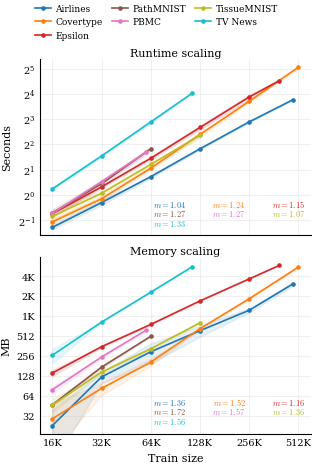

In [48]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

df_dataset = pd.read_csv("/Users/aumona/Projects/RF-GAP-Python/experiments/results/ablation_last/dataset/dataset_results.csv")
# df_dataset = pd.read_csv("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260412_020806_ablation/dataset/dataset_results.csv")


SELECTED_DATASETS = [
    # "higgs",
    # "susy",
    "airlines",
    # "celegans",
    "covertype",
    "epsilon",
    # "nsl_kdd+",
    # "sign_mnist",
    "pathmnist_28",
    "pbmc",
    "tissuemnist_28",
    "tv_news_combined",
    # "zilionis",
]

# Keep only points with n_train_subset >= 2**MIN_POW
MIN_POW = 14

# Use the same number of columns for the top legend and the m=... layout
N_COL_LEG = 3

# Error band options
PLOT_ERROR_BANDS = True
BAND_TYPE = "std"   # choose between: "se" or "std"

# Slope text options
SHOW_SLOPE_TEXT = True
N_TAIL = 30   # fit on last N_TAIL points; if N_TAIL >= n_points, fit whole curve

# SIAM single-column width
COLUMN_WIDTH_PT = 241.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = COLUMN_WIDTH_PT * PT_TO_IN
FIG_HEIGHT = 4.6

SAVE_BASENAME = f"dataset_ablation_two_panel_single_column_kgeq{MIN_POW}"
FIG_DIR = Path("./compiled_dataset_ablation_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


DATASET_DISPLAY_NAMES = {
    "higgs": "Higgs",
    "susy": "SUSY",
    "airlines": "Airlines",
    "celegans": "CElegans",
    "covertype": "Covertype",
    "epsilon": "Epsilon",
    "nsl_kdd+": "NSL-KDD+",
    "pathmnist_28": "PathMNIST",
    "pbmc": "PBMC",
    "sign_mnist": "SignMNIST",
    "tissuemnist_28": "TissueMNIST",
    "tv_news_combined": "TV News",
    "zilionis": "Zilionis",
}


def dataset_plot_title(name: str) -> str:
    return DATASET_DISPLAY_NAMES.get(name, name)


def summarize_curve(df: pd.DataFrame, y_col: str) -> pd.DataFrame:
    out = (
        df.groupby(["dataset", "n_train_subset"], as_index=False)[y_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    out["sem"] = out["std"] / np.sqrt(out["count"])

    out["lower_se"] = out["mean"] - out["sem"]
    out["upper_se"] = out["mean"] + out["sem"]

    out["lower_std"] = out["mean"] - out["std"]
    out["upper_std"] = out["mean"] + out["std"]

    return out.sort_values(["dataset", "n_train_subset"]).reset_index(drop=True)


def fit_log2_slope(x, y, n_tail=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if n_tail is not None and n_tail > 0 and len(x) > n_tail:
        x = x[-n_tail:]
        y = y[-n_tail:]

    if len(x) < 2:
        return np.nan

    m, _ = np.polyfit(np.log2(x), np.log2(y), 1)
    return float(m)


def pow2_count_formatter(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    x_int = int(round(x))

    if x_int >= 2**20:
        val = x_int / 2**20
        return f"{val:.0f}M" if abs(val - round(val)) < 1e-8 else f"{val:.1f}M"
    if x_int >= 2**10:
        val = x_int / 2**10
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"
    return f"{x_int}"


def format_mem_tick_binary(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    if x >= 1024:
        val = x / 1024
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"

    return f"{int(round(x))}" if abs(x - round(x)) < 1e-8 else f"{x:.0f}"


def should_keep_last_point(n_last: int) -> bool:
    if n_last <= 0:
        return True

    if (n_last & (n_last - 1)) == 0:
        return True

    k_floor = int(np.floor(np.log2(n_last)))
    prev_pow = 2 ** k_floor
    next_pow = 2 ** (k_floor + 1)

    dist_prev = n_last - prev_pow
    dist_next = next_pow - n_last

    return dist_next < dist_prev


def truncate_last_endpoint(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    datasets_to_drop_last = {}

    for dataset_name, g in df.groupby("dataset"):
        sizes = np.sort(g["n_train_subset"].unique())
        if len(sizes) == 0:
            continue

        last_n = int(sizes[-1])
        keep_last = should_keep_last_point(last_n)
        datasets_to_drop_last[dataset_name] = None if keep_last else last_n

    keep_mask = np.ones(len(df), dtype=bool)

    for dataset_name, last_n_to_drop in datasets_to_drop_last.items():
        if last_n_to_drop is None:
            continue
        keep_mask &= ~(
            (df["dataset"] == dataset_name)
            & (df["n_train_subset"] == last_n_to_drop)
        )

    return df.loc[keep_mask].copy()


def add_ordered_slope_grid(
    ax,
    slope_items,
    ncol,
    x_right=0.98,
    y_bottom=0.04,
    col_width=0.22,
    row_height=0.055,
    fontsize=6.0,
):
    """
    Draw colored slope labels inside an axes, using the same row-wise ordering
    as a legend with ncol=ncol.
    """
    if len(slope_items) == 0:
        return

    n_items = len(slope_items)
    n_rows = math.ceil(n_items / ncol)

    for idx, (color, text) in enumerate(slope_items):
        row = idx // ncol
        col = idx % ncol

        # Row-wise ordering, anchored as a block at bottom-right
        x = x_right - (ncol - 1 - col) * col_width
        y = y_bottom + (n_rows - 1 - row) * row_height

        ax.text(
            x,
            y,
            text,
            color=color,
            fontsize=fontsize,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
        )


assert "df_dataset" in globals(), "Please load df_dataset before running this cell."

if BAND_TYPE not in {"se", "std"}:
    raise ValueError("BAND_TYPE must be either 'se' or 'std'.")

df_plot = df_dataset.copy()

df_plot["kernel_pipeline_time_s"] = (
    df_plot["cache_build_time_s"].fillna(0)
    + df_plot["q_build_time_s"].fillna(0)
    + df_plot["full_kernel_time_s"].fillna(0)
)

df_plot["kernel_pipeline_peak_mb"] = df_plot[
    ["cache_build_peak_mb", "q_build_peak_mb", "full_kernel_peak_mb"]
].fillna(0).max(axis=1)

if "status" in df_plot.columns:
    df_plot = df_plot[df_plot["status"] == "ok"].copy()

df_plot = truncate_last_endpoint(df_plot)

available_datasets = sorted(df_plot["dataset"].unique())
missing = [ds for ds in SELECTED_DATASETS if ds not in available_datasets]
if missing:
    raise ValueError(f"These selected datasets are missing from df_plot: {missing}")

PLOT_DATASETS = SELECTED_DATASETS

time_summary = summarize_curve(df_plot, "kernel_pipeline_time_s")
mem_summary = summarize_curve(df_plot, "kernel_pipeline_peak_mb")

print("Datasets to plot:", PLOT_DATASETS)
print(f"Plot error bands: {PLOT_ERROR_BANDS}")
print(f"Band type: {BAND_TYPE}")
print(f"Show slope text: {SHOW_SLOPE_TEXT}")
print(f"N_TAIL: {N_TAIL}")
print(f"N_COL_LEG: {N_COL_LEG}")

print("\nRemaining train sizes by dataset:")
for ds in PLOT_DATASETS:
    sizes = sorted(df_plot.loc[df_plot["dataset"] == ds, "n_train_subset"].unique())
    print(ds, sizes)

display(time_summary.head())
display(mem_summary.head())


# quick summary table for sanity check
summary_table = (
    df_plot.groupby("dataset", as_index=False)
    .agg(
        n_train_max=("n_train_subset", "max"),
        time_max_s=("kernel_pipeline_time_s", "max"),
        mem_max_mb=("kernel_pipeline_peak_mb", "max"),
    )
)

summary_table["dataset_display"] = summary_table["dataset"].map(dataset_plot_title)
display(summary_table.sort_values("dataset_display"))


# plotting combined
min_n = 2 ** MIN_POW

fig, axes = plt.subplots(
    2, 1,
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharex=True,
    squeeze=False
)
ax_runtime = axes[0, 0]
ax_memory = axes[1, 0]

ax_runtime.spines["right"].set_visible(False)
ax_memory.spines["right"].set_visible(False)
ax_runtime.yaxis.set_ticks_position("left")
ax_memory.yaxis.set_ticks_position("left")

colors = plt.cm.tab10(np.linspace(0, 1, len(PLOT_DATASETS)))

legend_handles = []
legend_labels = []

runtime_slope_text = []
memory_slope_text = []

lower_col = f"lower_{BAND_TYPE}"
upper_col = f"upper_{BAND_TYPE}"

# Store band data and plot mean curves first
runtime_band_data = []
memory_band_data = []

for color, dataset_name in zip(colors, PLOT_DATASETS):
    dt = (
        time_summary[
            (time_summary["dataset"] == dataset_name)
            & (time_summary["n_train_subset"] >= min_n)
        ]
        .copy()
        .sort_values("n_train_subset")
    )
    dm = (
        mem_summary[
            (mem_summary["dataset"] == dataset_name)
            & (mem_summary["n_train_subset"] >= min_n)
        ]
        .copy()
        .sort_values("n_train_subset")
    )

    if len(dt) < 2 or len(dm) < 2:
        print(f"Skipping {dataset_name}: not enough points after filtering.")
        continue

    x_t = dt["n_train_subset"].to_numpy()
    y_t = dt["mean"].to_numpy()
    lo_t = dt[lower_col].to_numpy()
    up_t = dt[upper_col].to_numpy()

    x_m = dm["n_train_subset"].to_numpy()
    y_m = dm["mean"].to_numpy()
    lo_m = dm[lower_col].to_numpy()
    up_m = dm[upper_col].to_numpy()

    # Plot mean curves first so autoscaling is based only on the means
    line_t, = ax_runtime.plot(
        x_t, y_t,
        color=color,
        linestyle="-",
        marker="o",
        markersize=2.3,
        linewidth=1.2,
        zorder=3,
    )

    ax_memory.plot(
        x_m, y_m,
        color=color,
        linestyle="-",
        marker="o",
        markersize=2.3,
        linewidth=1.2,
        zorder=3,
    )

    # Save band data for later plotting
    runtime_band_data.append((x_t, lo_t, up_t, color))
    memory_band_data.append((x_m, lo_m, up_m, color))

    legend_handles.append(line_t)
    legend_labels.append(dataset_plot_title(dataset_name))

    if SHOW_SLOPE_TEXT:
        m_t = fit_log2_slope(x_t, y_t, n_tail=N_TAIL)
        m_m = fit_log2_slope(x_m, y_m, n_tail=N_TAIL)
    
        runtime_slope_text.append(
            (color, rf"$m={m_t:.2f}$" if np.isfinite(m_t) else r"$m=\mathrm{nan}$")
        )
        memory_slope_text.append(
            (color, rf"$m={m_m:.2f}$" if np.isfinite(m_m) else r"$m=\mathrm{nan}$")
        )

for ax in [ax_runtime, ax_memory]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log", base=2)
    ax.grid(True, alpha=0.18, zorder=0)
    ax.tick_params(axis="x", which="both", length=0, colors="black")
    ax.tick_params(axis="y", which="both", length=0, colors="black")
    ax.xaxis.set_major_formatter(FuncFormatter(pow2_count_formatter))

# Freeze limits based on mean curves only
ax_runtime.relim()
ax_runtime.autoscale_view()
runtime_xlim = ax_runtime.get_xlim()
runtime_ylim = ax_runtime.get_ylim()

ax_memory.relim()
ax_memory.autoscale_view()
memory_xlim = ax_memory.get_xlim()
memory_ylim = ax_memory.get_ylim()

# Add error bands after autoscaling, then restore limits
if PLOT_ERROR_BANDS:
    for x_t, lo_t, up_t, color in runtime_band_data:
        ax_runtime.fill_between(
            x_t, lo_t, up_t,
            color=color,
            alpha=0.10,
            zorder=1,
        )

    for x_m, lo_m, up_m, color in memory_band_data:
        ax_memory.fill_between(
            x_m, lo_m, up_m,
            color=color,
            alpha=0.10,
            zorder=1,
        )

    ax_runtime.set_xlim(runtime_xlim)
    ax_runtime.set_ylim(runtime_ylim)
    ax_memory.set_xlim(memory_xlim)
    ax_memory.set_ylim(memory_ylim)

ax_runtime.set_title("Runtime scaling", pad=2)
ax_memory.set_title("Memory scaling", pad=2)

ax_runtime.set_ylabel("Seconds")
ax_memory.set_ylabel("MB")
ax_memory.set_xlabel("Train size")

ax_memory.yaxis.set_major_formatter(FuncFormatter(format_mem_tick_binary))

if SHOW_SLOPE_TEXT:
    add_ordered_slope_grid(
        ax_runtime,
        runtime_slope_text,
        ncol=N_COL_LEG,
        x_right=0.98,
        y_bottom=0.04,
        col_width=0.22,
        row_height=0.055,
        fontsize=6.0,
    )

    add_ordered_slope_grid(
        ax_memory,
        memory_slope_text,
        ncol=N_COL_LEG,
        x_right=0.98,
        y_bottom=0.04,
        col_width=0.22,
        row_height=0.055,
        fontsize=6.0,
    )

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=N_COL_LEG,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.0,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])

out_base = FIG_DIR / SAVE_BASENAME
suffix_parts = []
suffix_parts.append(f"kgeq{MIN_POW}")
suffix_parts.append(f"bands-{BAND_TYPE}" if PLOT_ERROR_BANDS else "nobands")
suffix_parts.append(f"slopes-tail{N_TAIL}" if SHOW_SLOPE_TEXT else "noslopes")
suffix_parts.append(f"ncolleg-{N_COL_LEG}")
out_base = FIG_DIR / f"dataset_ablation_two_panel_single_column_{'_'.join(suffix_parts)}"

fig.savefig(out_base.with_suffix(".pdf"))
fig.savefig(out_base.with_suffix(".png"), dpi=300)

plt.show()